# Blackbox Optimisation Project: Week Four


This extends the boundary box approach from week 2. Rather than manually specifying a a bounding box from inspection of the input-output scatter, this code classifies the data with a binary "promising" channel.  <br><br> -- Data points with an output in the upper quartile of values are given a "promising" value of 1, others are 0 <br> -- A convex hull is then drawn around the subset of points defined as being "promising" <br> -- This convex hull i sthen searched for the most-isolated point as in week 1, but the search region is now concentrated around points that appear to be close to the maximum

In [2]:
week = 4

Import Standard Libraries

In [3]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path
import copy
import matplotlib.pyplot as plt

from sklearn import svm

Import Project Packages

In [4]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

## Import data and create output directories

In [5]:
function = 8

In [6]:
# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)
print(f"Requested function {function} in week {week}")

Requested function 8 in week 4


In [7]:
# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"results will be saved to {results_dir}")

results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_4\function_8


In [8]:
# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)


Loaded initial data: function_8


In [9]:
# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)


Available update files:
1: new_data_point_wk1.csv
2: new_data_point_wk2.csv
3: new_data_point_wk3.csv
Added 3 new data points.


## Augment data set

In [10]:
# separate inputs from outputs
input_cols = data_loading.get_X_cols(df)

In [11]:
# Scale the outputs
df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])

#### Classify promising regions

In [ ]:
quantile = 0.5
threshold = df["YScaled"].quantile(quantile)

while (df["YScaled"] >= threshold).astype(int).sum() < len(input_cols) + 1:
    quantile = quantile - 0.05
    threshold = df["YScaled"].quantile(quantile)

df["promising"] = (df["YScaled"] >= threshold).astype(int)

##### Fit SVM to find decision boundary between promising and unpromising regions

Use a grid search with 5-fold cross validation to set SVMs hyperparameters 

In [13]:
df_svm = df.drop(columns=["Y1", "new data point", "YScaled"])

In [14]:
folds =  data_augmentation.k_folds(df_svm, 5)

In [15]:
# grid_params = np.concatenate([
#     np.arange(0.01, 0.1, 0.02),
#     np.arange(0.1, 1, 0.2),
#     np.arange(1, 10, 0.5)
# ]).tolist()

# grid_params = np.logspace(np.log10(0.01), np.log10(10), 50)
grid_params = np.arange(0,10,0.2)
grid_params += 0.01

In [16]:
G, C, A = list(),list(),list()
for gam in grid_params:
    for pen in grid_params:

        RMSE_SVM = data_augmentation.cross_validation(copy.copy(folds),input_cols, gam, pen)

        G.append(gam)
        C.append(pen)
        A.append(RMSE_SVM)

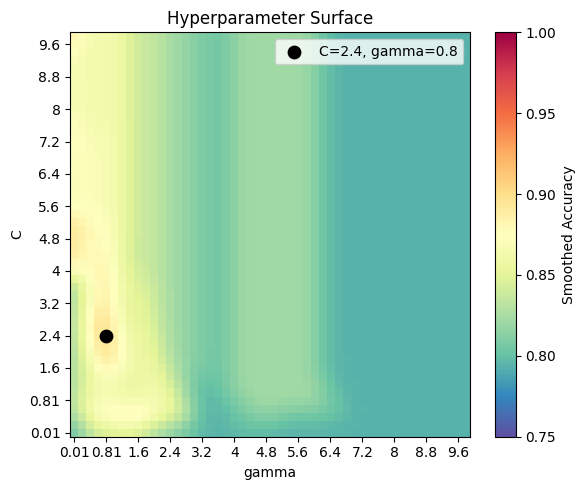

Best Parameters:
C = 2.41
gamma = 0.81
Accuracy = 0.8932759356737232


In [17]:
svm_cross_validation = pd.DataFrame({
    "gamma": G,
    "C": C,
    "Accuracy": A
})

C_best, gamma_best = data_plotting.plot_hyperparameter_surface(svm_cross_validation,results_dir)

Fit SVM to whole dataset using best hyperparamters as determined by 5-fold cross validation

In [18]:
X = df_svm[input_cols].to_numpy()
y = df_svm["promising"].to_numpy().ravel()
weight = int(1/np.divide(len(df_svm[df_svm["promising"] == 1]),len(df_svm)))

SVM = svm.SVC(kernel='rbf', gamma = gamma_best, C = C_best, class_weight={0: weight, 1: 1})
SVM.fit(X, y)
df_svm["prediction"] = SVM.predict(X)

accuracy_all = data_augmentation.accuracy(df_svm['prediction'].to_numpy(), df_svm['promising'].to_numpy())
print(accuracy_all)

0.9767441860465116


In [19]:
lhs_samples = data_augmentation.generate_lhc(X.shape[1])
lhs_df = pd.DataFrame(lhs_samples, columns=input_cols)

lhs_df["promising"] = SVM.predict(lhs_samples)
lhs_df = lhs_df[lhs_df["promising"] == 1]


In [20]:
df_inputs = df[input_cols]
df_output = df["YScaled"]

Find most isolated point in the input space, bound by the convex hull of all inputs data

In [21]:
df_hull_inputs = lhs_df[input_cols]

In [22]:
hull, points_hull = data_augmentation.compute_convex_hull(df_hull_inputs)

In [23]:
hull

In [ ]:
best_point, best_dist = data_augmentation.most_isolated_point(points_hull, hull, n_samples=2000, seed=42)

# def to_dict(point, columns):
#     return {col: val for col, val in zip(columns, point)}

# best_point_dict = to_dict(best_point, input_cols)

generating random seeds...
generating points array...
calculating dimensions...
Delaunay


## Plot Results

In [ ]:
points = df_inputs.to_numpy()
new_point_flag = df["new data point"].to_numpy()

KeyError: 'X5'

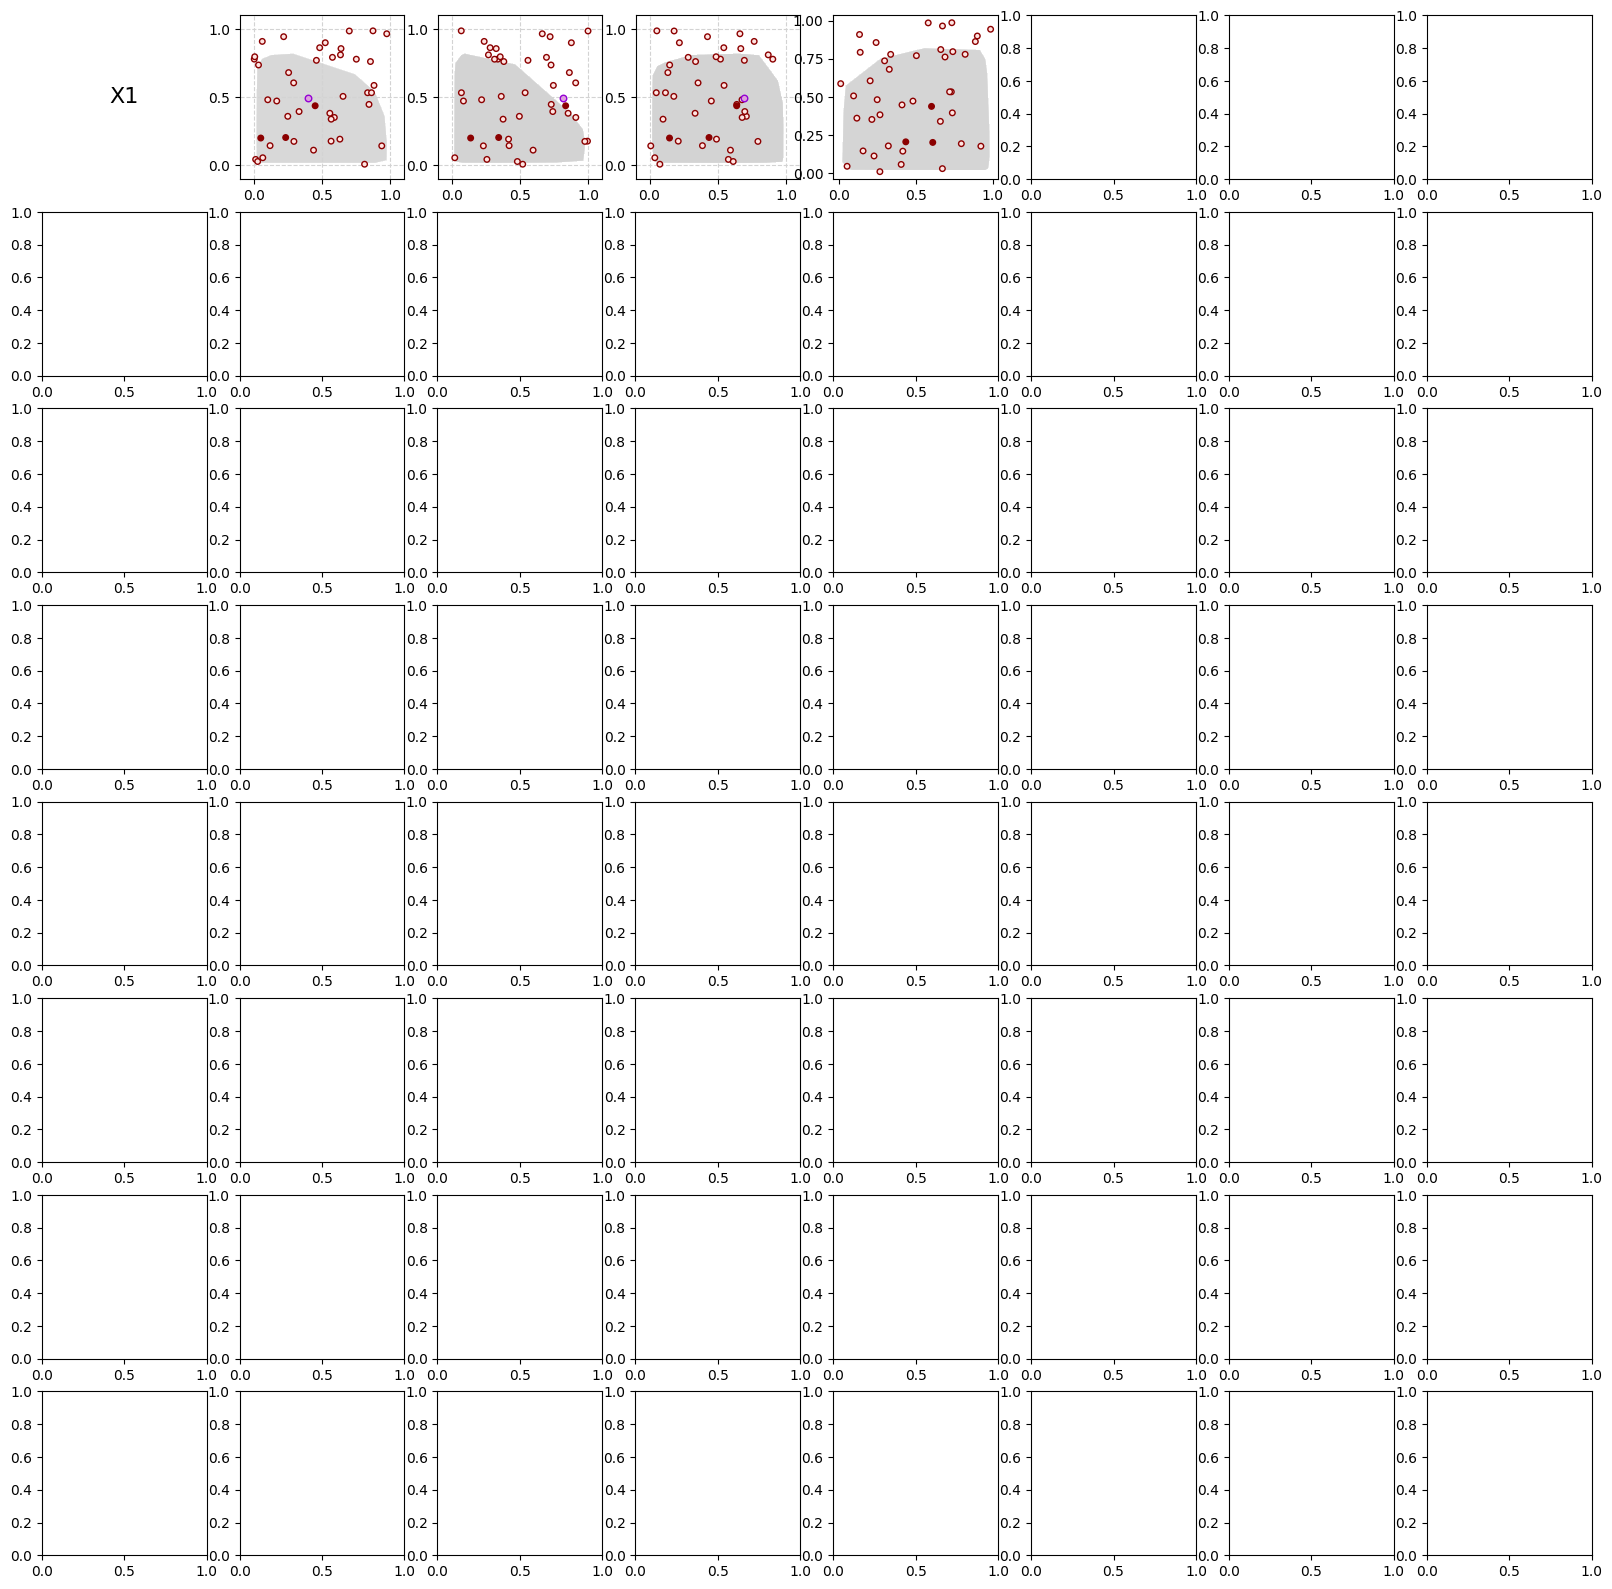

In [ ]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, hull = hull,next_point = best_point_dict)

In [ ]:
X = df_inputs.to_numpy()
Y = df_output.to_numpy()

Y = np.asarray(Y).reshape(-1, 1)
Z = df["promising"].to_numpy().reshape(-1, 1) 

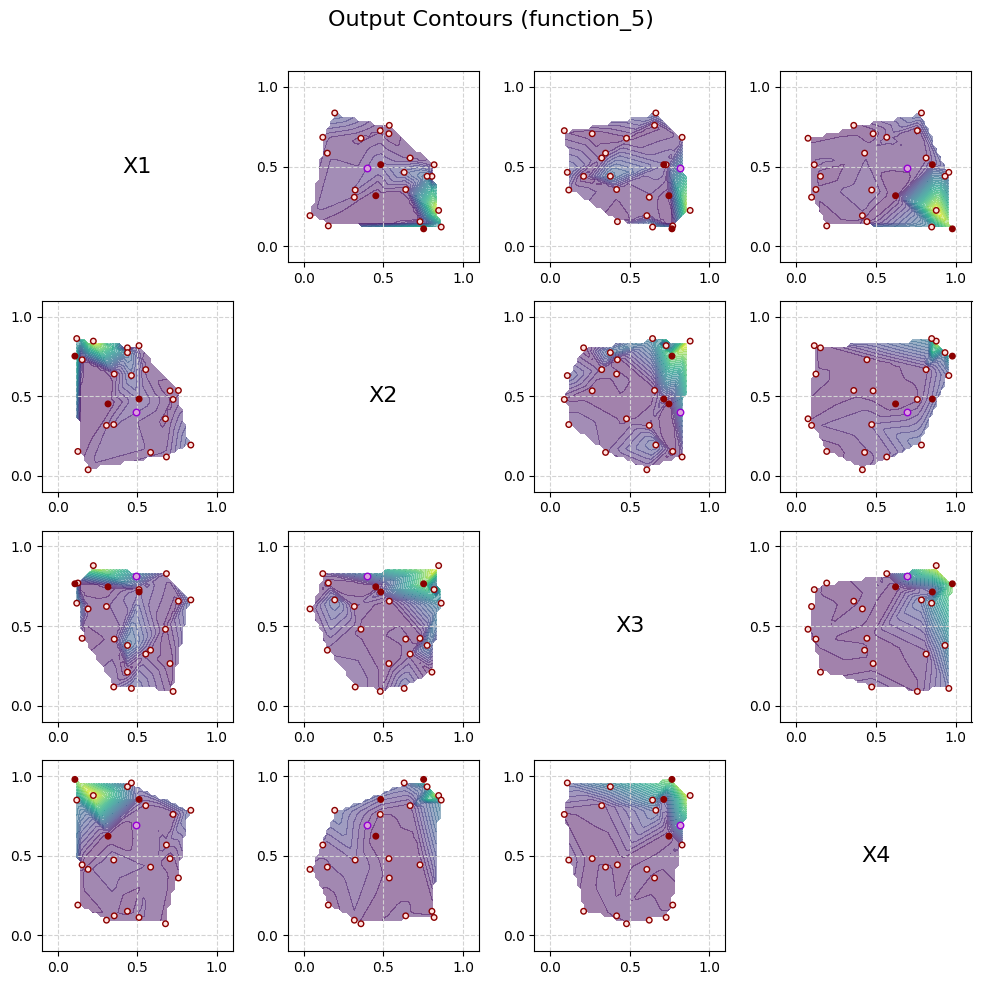

In [ ]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, contour = Y[:, 0],next_point = best_point_dict)

(<Figure size 1000x250 with 4 Axes>,
 array([[<Axes: xlabel='X1', ylabel='Y1'>, <Axes: xlabel='X2'>,
         <Axes: xlabel='X3'>, <Axes: xlabel='X4'>]], dtype=object))

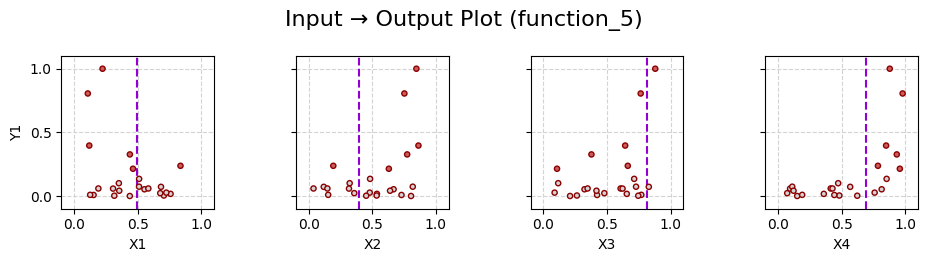

In [ ]:
data_plotting.domain_io_plot(data_folder_name,results_dir,input_cols,["Y1"],X,Y,Z,next_point=best_point_dict)

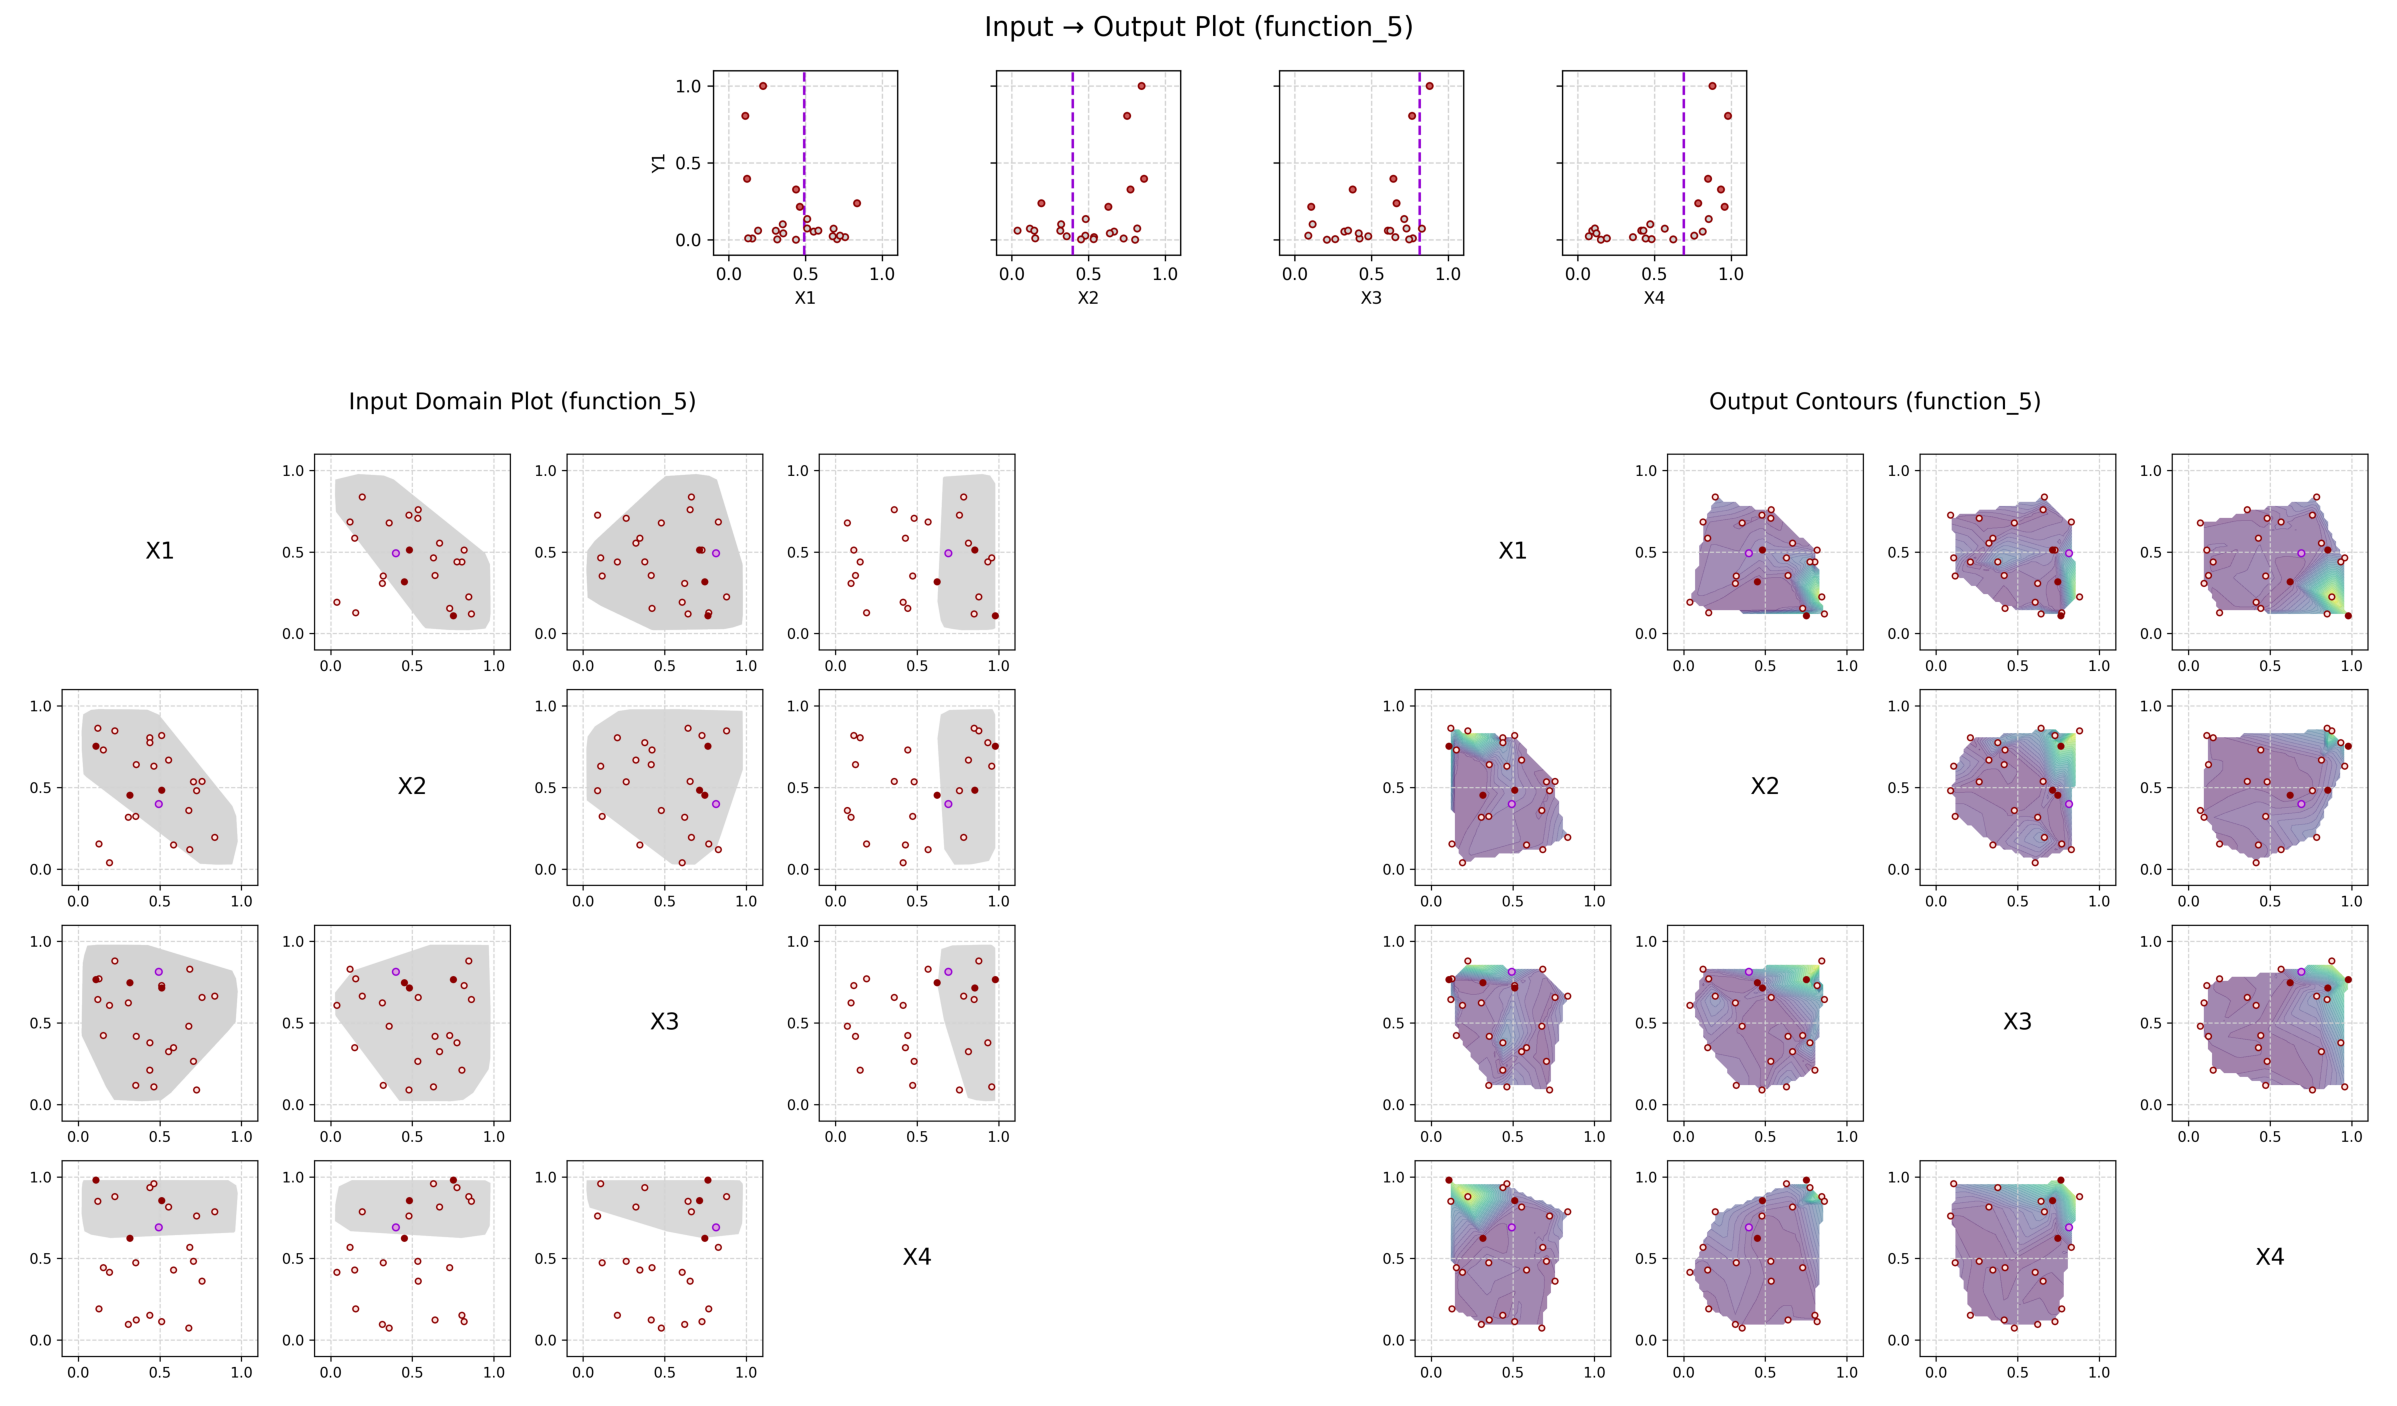

In [ ]:
import matplotlib.image as mpimg

# Create a figure and a grid layout
fig = plt.figure(figsize=(32, 18))
gs = fig.add_gridspec(4,2)

# # Map
search_region_path = results_dir / ("domain_scatter.png")
output_contour_path = results_dir / ("domain_scatter_contour.png")
io_path = results_dir / ("io_scatter.png")

search_region = mpimg.imread(search_region_path)
output_contour = mpimg.imread(output_contour_path)
io = mpimg.imread(io_path)

ax1 = fig.add_subplot(gs[1:,0])
ax1.imshow(search_region)
ax1.axis('off')

ax2 = fig.add_subplot(gs[1:,1])
ax2.imshow(output_contour)
ax2.axis('off')

ax3 = fig.add_subplot(gs[0,:])
ax3.imshow(io)
ax3.axis('off')

save_filename = results_dir / "collated_results.png"
plt.savefig(save_filename, dpi=300)

#### write next point to csv

In [ ]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [ ]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.492789-0.398193-0.814784-0.691796
